In [13]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns 


In [14]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [15]:
file_path = 'C:\\Users\\zalew\\OneDrive\\Desktop\\Projects\\Feature-Engineering-Building-ML-Pipeline-\\data\\processed_data.csv'
df = pd.read_csv(file_path)

# Display basic information about dataset shape
shape_of_df = df.shape
print(f"Dataset shape: {shape_of_df[0]} rows × {shape_of_df[1]} columns")
shape_of_df

Dataset shape: 1217 rows × 19 columns


(1217, 19)

In [16]:

df.head(20)

,numeric__Model_Year,numeric__Mileage,numeric__Engine_Size,horsepower__Horsepower,other_numeric__Doors,other_numeric__Owner_Count,other_numeric__Owner_Count.1,categorical__Brand_BMW,categorical__Brand_Ford,categorical__Brand_Honda,categorical__Brand_Hyundai,categorical__Brand_Tesla,categorical__Brand_Toyota,categorical__Transmission_Automatic,categorical__Transmission_Manual,categorical__Fuel_Type_diesel,categorical__Fuel_Type_electric,categorical__Fuel_Type_hybrid,categorical__Fuel_Type_petrol
0,0.0,0.599587,0.785714,1.450955,0.0,0.000000,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,-0.016609,-1.142857,1.925444,1.0,0.666667,0.666667,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,0.6,0.431535,0.428571,0.110522,0.0,0.333333,0.333333,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.000000,0.000000,-0.933354,0.0,0.000000,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,0.6,-0.991616,0.000000,-0.043687,1.0,0.333333,0.333333,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5,0.6,1.217545,0.642857,1.450955,0.0,0.333333,0.333333,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
6,0.0,0.477226,-0.214286,-0.186033,0.0,0.333333,0.333333,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
7,0.2,0.000000,-1.142857,0.929017,0.0,1.000000,1.000000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
8,0.6,-1.045648,0.500000,-1.253635,0.0,1.000000,1.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
9,-0.4,-0.157298,1.214286,-0.091135,0.5,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [17]:
column_names = list(df.columns)
missing_val_count=df.isna().sum()
missing_val_df=pd.DataFrame({
        'column_name': column_names,
     'missing_values': missing_val_count,
     "missing %": (missing_val_count / len(df) * 100).round(2)
})
missing_val_df_filtered = missing_val_df[missing_val_df["missing_values"] > 0]

if len(missing_val_df_filtered) > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x='column_name', y='missing_values', data=missing_val_df_filtered)
    plt.title('Missing Values Count by Column')
    plt.xlabel('Column Name')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset")

No missing values found in the dataset


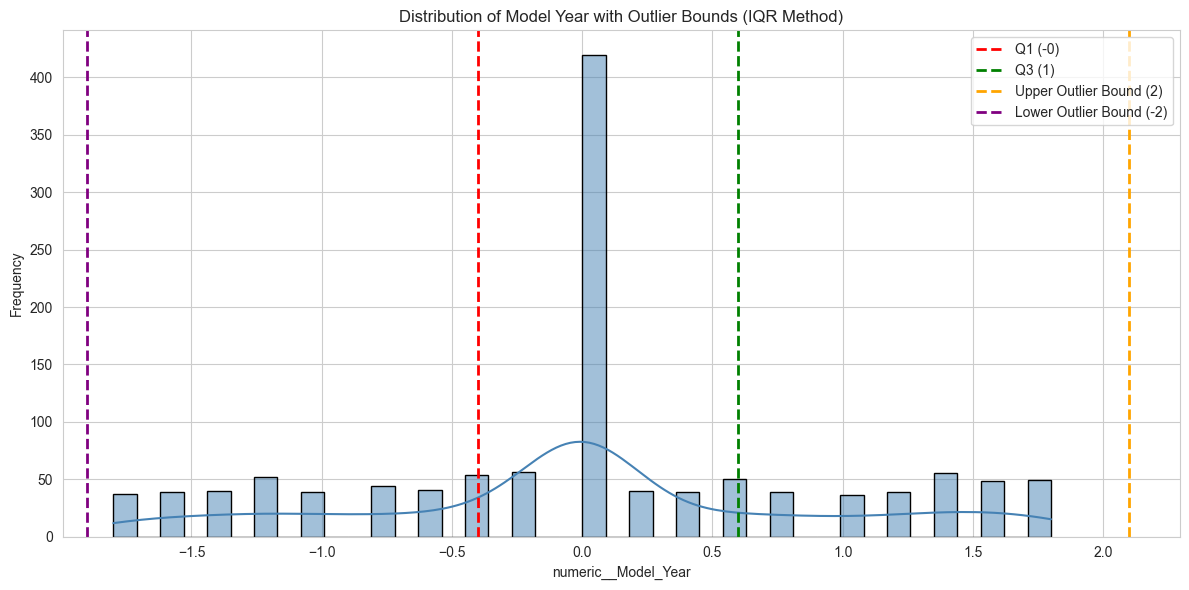

Model Year - Q1: -0.4, Q3: 0.6, IQR: 1.0, Upper Bound: 2.1, Lower Bound: -1.9


In [20]:
Q1 = df['numeric__Model_Year'].quantile(0.25)
Q3 = df['numeric__Model_Year'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df['numeric__Model_Year'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.axvline(lower_bound, color='purple', linestyle='--', linewidth=2, label=f'Lower Outlier Bound ({lower_bound:.0f})')
plt.legend()
plt.title('Distribution of Model Year with Outlier Bounds (IQR Method)')
plt.xlabel('numeric__Model_Year')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Model Year - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")

In [22]:
print(df['numeric__Mileage'].describe())

count    1217.000000
mean       -0.014415
std         0.722207
min        -1.409274
25%        -0.521530
50%         0.000000
75%         0.478470
max         1.407511
Name: numeric__Mileage, dtype: float64


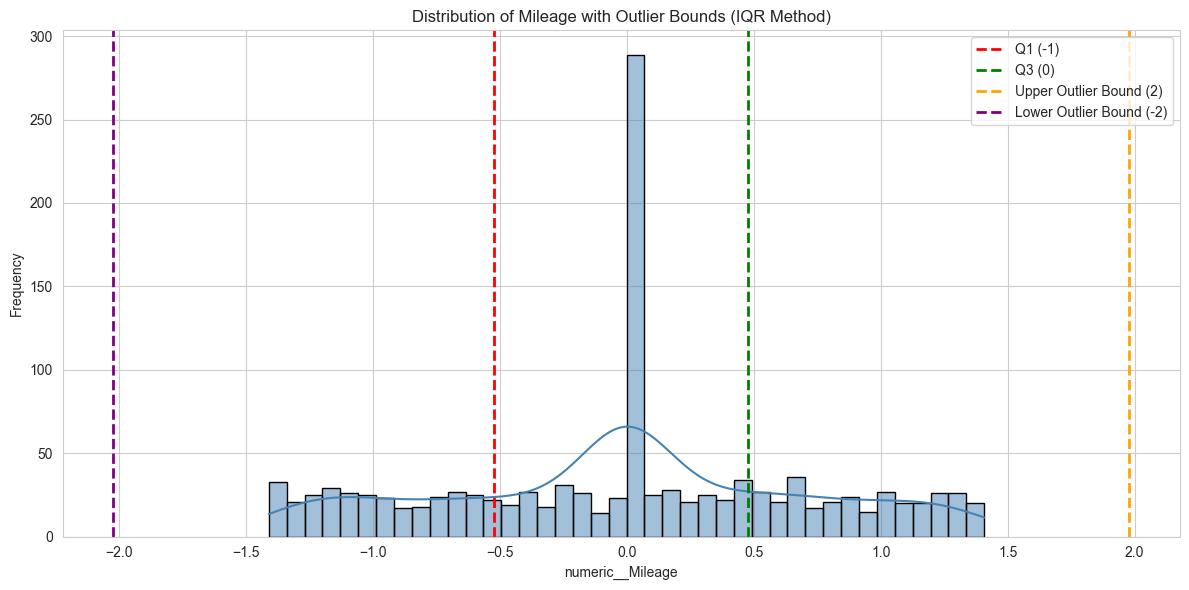

Mileage - Q1: -0.521530478021422, Q3: 0.4784695219785779, IQR: 1.0, Upper Bound: 1.978469521978578, Lower Bound: -2.021530478021422


In [23]:
Q1 = df['numeric__Mileage'].quantile(0.25)
Q3 = df['numeric__Mileage'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df['numeric__Mileage'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.axvline(lower_bound, color='purple', linestyle='--', linewidth=2, label=f'Lower Outlier Bound ({lower_bound:.0f})')
plt.legend()
plt.title('Distribution of Mileage with Outlier Bounds (IQR Method)')
plt.xlabel('numeric__Mileage')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Mileage - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")

In [29]:
print(df['other_numeric__Doors'].describe())

count    1217.000000
mean        0.396878
std         0.419320
min         0.000000
25%         0.000000
50%         0.500000
75%         1.000000
max         1.000000
Name: other_numeric__Doors, dtype: float64


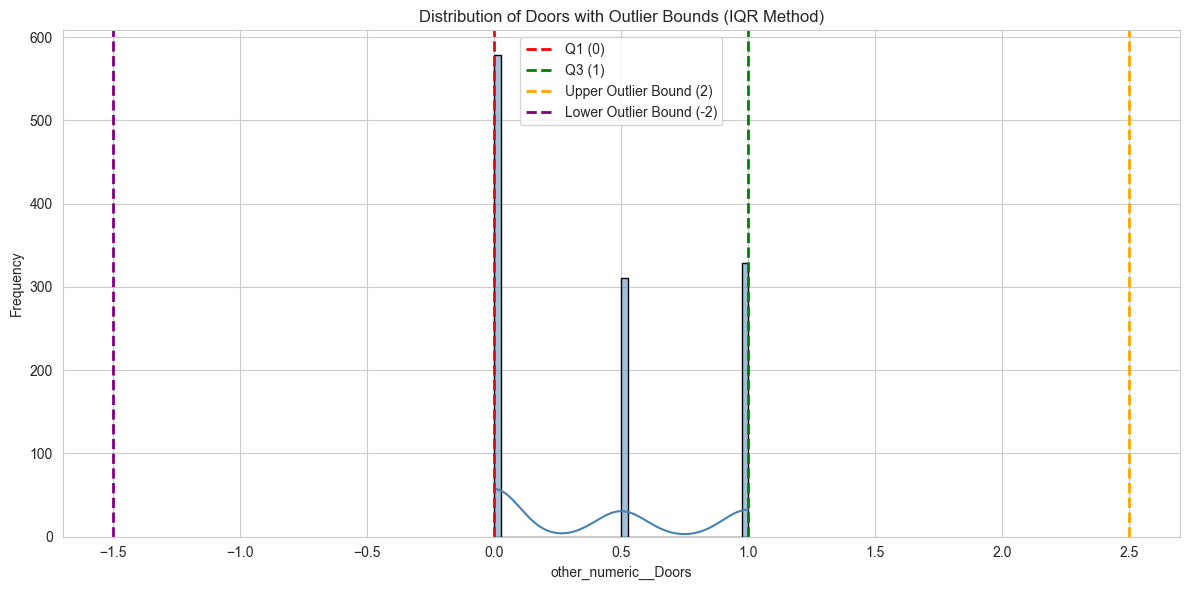

Doors - Q1: 0.0, Q3: 1.0, IQR: 1.0, Upper Bound: 2.5, Lower Bound: -1.5


In [30]:
Q1 = df['other_numeric__Doors'].quantile(0.25)
Q3 = df['other_numeric__Doors'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df['other_numeric__Doors'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.axvline(lower_bound, color='purple', linestyle='--', linewidth=2, label=f'Lower Outlier Bound ({lower_bound:.0f})')
plt.legend()
plt.title('Distribution of Doors with Outlier Bounds (IQR Method)')
plt.xlabel('other_numeric__Doors')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Doors - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")

In [ ]:
print(df['Owner_Count'].describe())

count    1217.000000
mean        2.820049
std         1.176661
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         4.000000
Name: Owner_Count, dtype: float64


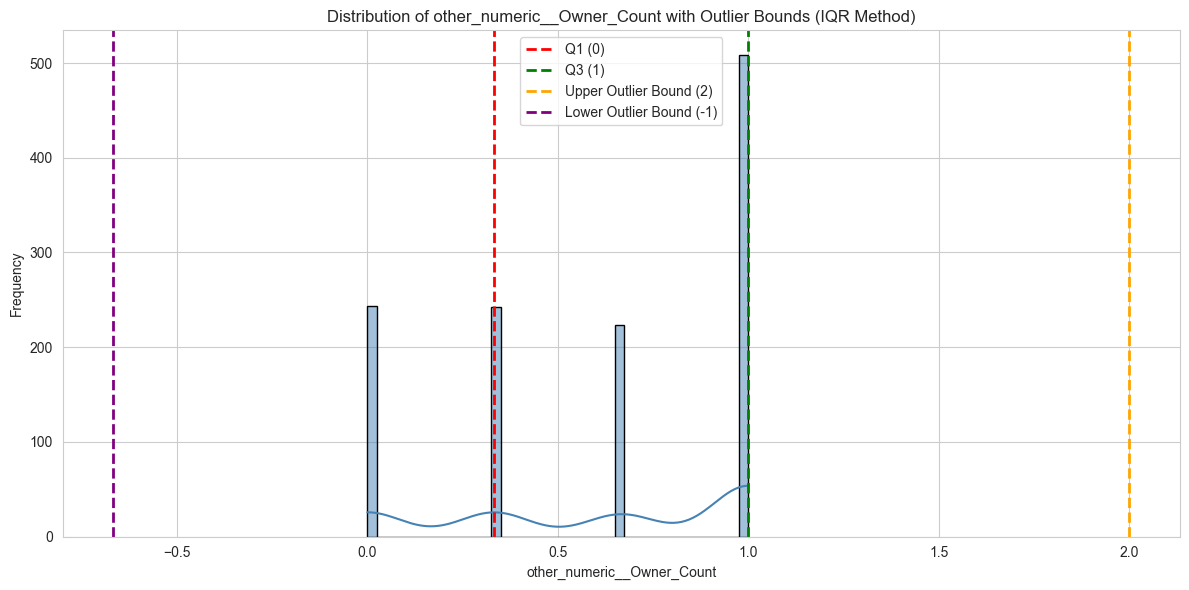

other_numeric__Owner_Count - Q1: 0.3333333333333333, Q3: 1.0, IQR: 0.6666666666666667, Upper Bound: 2.0, Lower Bound: -0.6666666666666667


In [32]:
Q1 = df['other_numeric__Owner_Count'].quantile(0.25)
Q3 = df['other_numeric__Owner_Count'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df['other_numeric__Owner_Count'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.axvline(lower_bound, color='purple', linestyle='--', linewidth=2, label=f'Lower Outlier Bound ({lower_bound:.0f})')
plt.legend()
plt.title('Distribution of other_numeric__Owner_Count with Outlier Bounds (IQR Method)')
plt.xlabel('other_numeric__Owner_Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"other_numeric__Owner_Count - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")

In [33]:
print(df['horsepower__Horsepower'].describe())

count    1.217000e+03
mean    -1.102013e-16
std      1.000411e+00
min     -1.941644e+00
25%     -6.723850e-01
50%     -3.182432e-02
75%      6.443231e-01
max      1.961031e+00
Name: horsepower__Horsepower, dtype: float64


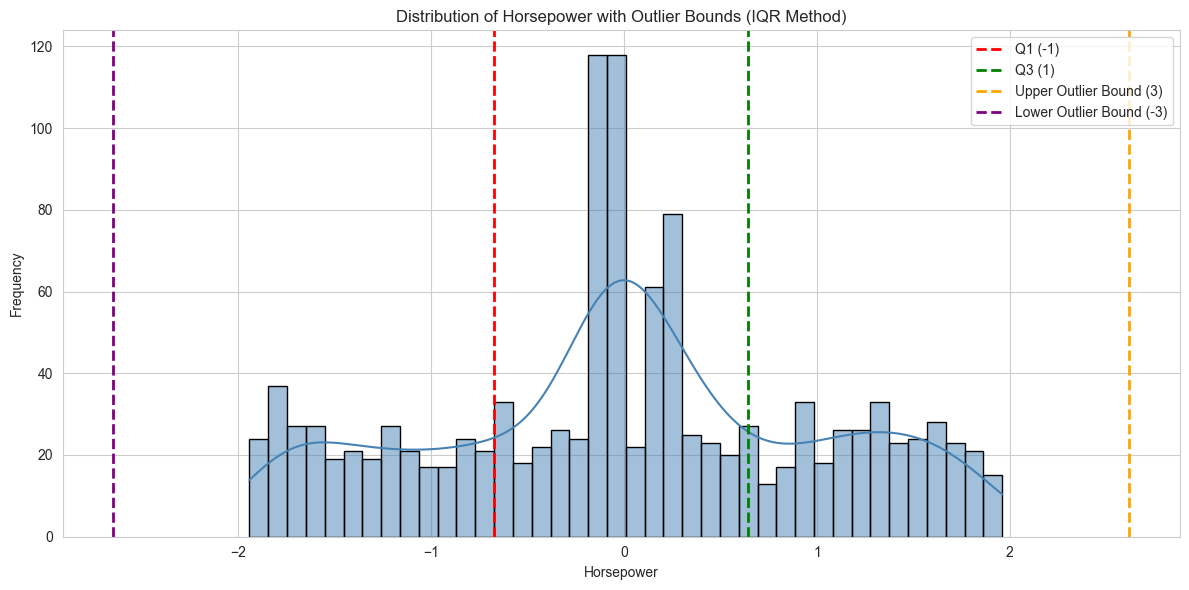

Horsepower - Q1: -0.6723850030218527, Q3: 0.644323068578585, IQR: 1.3167080716004378, Upper Bound: 2.6193851759792417, Lower Bound: -2.6474471104225095


In [34]:
Q1 = df['horsepower__Horsepower'].quantile(0.25)
Q3 = df['horsepower__Horsepower'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df['horsepower__Horsepower'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.axvline(lower_bound, color='purple', linestyle='--', linewidth=2, label=f'Lower Outlier Bound ({lower_bound:.0f})')
plt.legend()
plt.title('Distribution of Horsepower with Outlier Bounds (IQR Method)')
plt.xlabel('Horsepower')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Horsepower - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")

count    1217.000000
mean       -0.015436
std         0.729169
min        -1.428571
25%        -0.500000
50%         0.000000
75%         0.500000
max         1.428571
Name: numeric__Engine_Size, dtype: float64 

[ 0.78571429 -1.14285714  0.42857143  0.          0.64285714 -0.21428571
  0.5         1.21428571 -0.57142857 -1.28571429  0.14285714 -1.21428571
  0.57142857  0.28571429  1.14285714 -0.85714286 -0.28571429  1.35714286
  0.85714286 -0.64285714 -1.         -0.42857143 -0.78571429  0.92857143
  1.42857143 -0.5         0.71428571 -0.92857143  0.21428571  0.35714286
  1.          1.07142857 -0.07142857  0.07142857 -0.35714286 -1.35714286
 -0.14285714 -1.07142857  1.28571429 -0.71428571 -1.42857143]


Text(0.5, 1.0, 'Distribution of Engine Size')

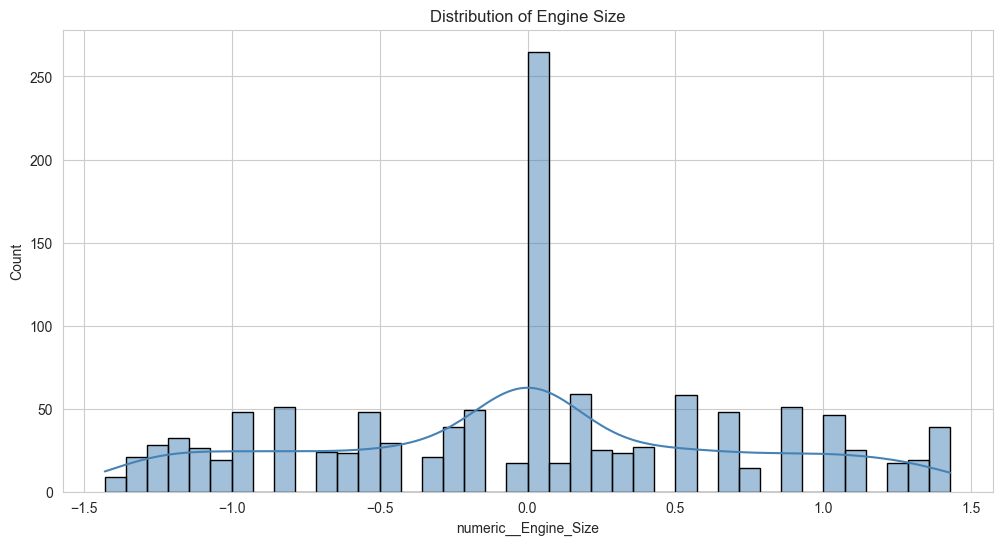

In [49]:
print(f'{df["numeric__Engine_Size"].describe()} \n')
print(df["numeric__Engine_Size"].unique())
sns.histplot(df["numeric__Engine_Size"], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.title('Distribution of Engine Size')